In [7]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter, medfilt

In [8]:
# Input folder file here
file_path1 = f"biomomentum_data/Creep_1.csv"
file_path2 = f"recorded_data/Black_Gel/_Creep_1.0min__Recover_1.0min/trial_5.csv"

In [9]:
def lvdt_csv_read(file_path):
    data = pd.read_csv(file_path, skiprows=1, header=None)
    time = data.iloc[:, 0].to_numpy()
    lvdt_disp = data.iloc[:,1].to_numpy()

    t_max = time.max()
    mask = (time >= t_max - 5000) & (time <= t_max)  # Change recording to n seconds before the end
    time = time[mask]
    time = time - time[0]  # Reset time to start from zero

    lvdt_disp = lvdt_disp[mask]
    lvdt_disp = medfilt(lvdt_disp, kernel_size=7)
    lvdt_disp = lvdt_disp - lvdt_disp[0]
    return np.vstack((time, lvdt_disp)).T


In [10]:
data = lvdt_csv_read(file_path1)

In [11]:
plot_title = "Skin Tissue Displacement Over Time"
x_label = "Time (s)"
y_label = "LVDT Displacement (mm)"
legend_1 = "Base data"

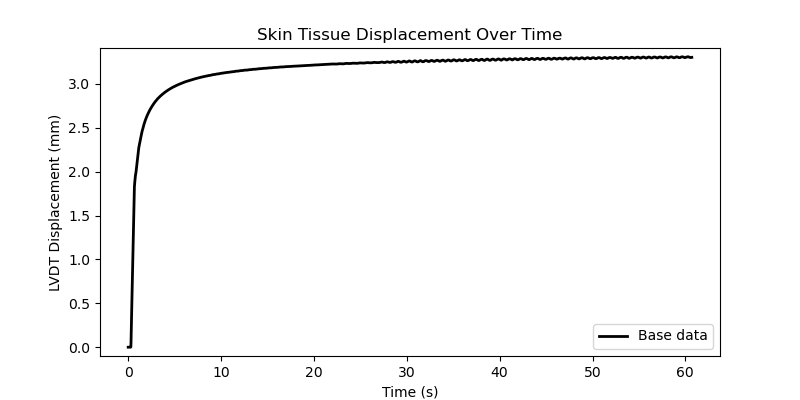

In [12]:
plt.figure(figsize=(8, 4))
plt.title(plot_title)
lw = 2
plt.plot(data[:,0], data[:,1], color = 'black', linewidth = lw, label = legend_1)
plt.ylim(min(data[:,1]) - 0.1, max(data[:,1]) + 0.1)
# plt.xlim(1, 2)
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.legend()
# plt.savefig(f"Normal_vs_pressured_limb_long_indent.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()